# Etapa 1 - Entendimento e Preparação

Este notebook documenta o processo de entendimento do problema, análise exploratória de dados e construção de um baseline com Regressão Logística.

Dataset utilizado Telco customer churn: IBM dataset.
https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset

ML Canvas com os requisitos e a documentação no docs:
[ML Canvas](../docs/ml_canvas.md)

Entendendo os dados 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

dataPath = Path("..") / "data" / "telco_customer_churn_original.xlsx"
df = pd.read_excel(dataPath)

df.head(5)

Matplotlib is building the font cache; this may take a moment.


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


Info e describe

In [47]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


                    Coluna  Missing_Count  Missing_Percentage
Churn Reason  Churn Reason           5174               73.46


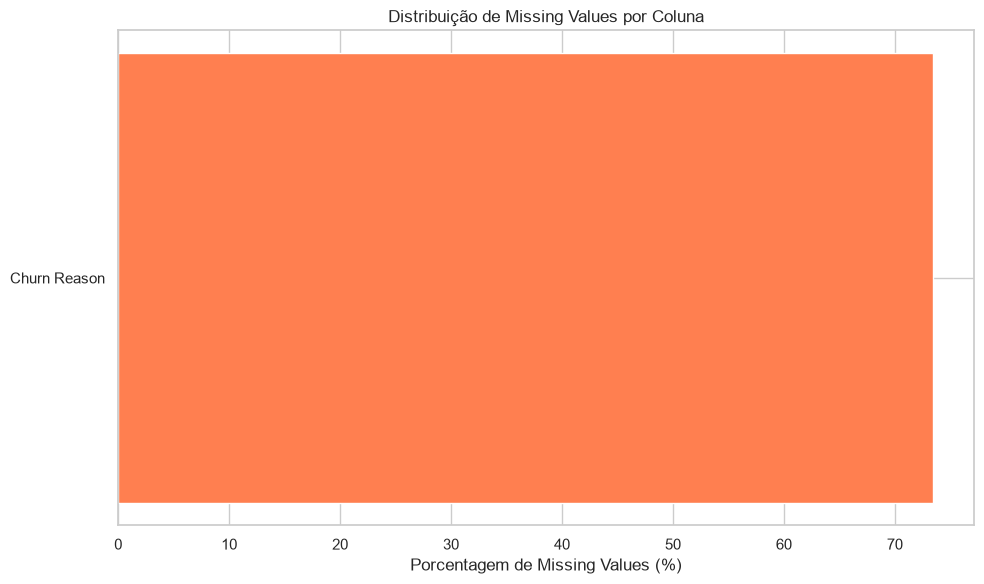

In [48]:
missing_values = pd.DataFrame(
    {
        "Coluna": df.columns,
        "Missing_Count": df.isnull().sum(),
        "Missing_Percentage": (df.isnull().sum() / len(df) * 100).round(2),
    }
)

missing_values = missing_values[missing_values["Missing_Count"] > 0].sort_values(
    by="Missing_Percentage", ascending=False
)

if len(missing_values) > 0:
    print(missing_values)

    # Visualizar missing values
    plt.figure(figsize=(10, 6))
    plt.barh(
        missing_values["Coluna"], missing_values["Missing_Percentage"], color="coral"
    )
    plt.xlabel("Porcentagem de Missing Values (%)")
    plt.title("Distribuição de Missing Values por Coluna")
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum missing value detectado!")

### Análise da Variável Target

**Objetivo:** Entender a distribuição da variável alvo (balanceamento de classes)

=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===

Contagem:
target
0    5174
1    1869
Name: count, dtype: int64

Percentual:
Não Churn (0): 73.46%
Churn (1): 26.54%


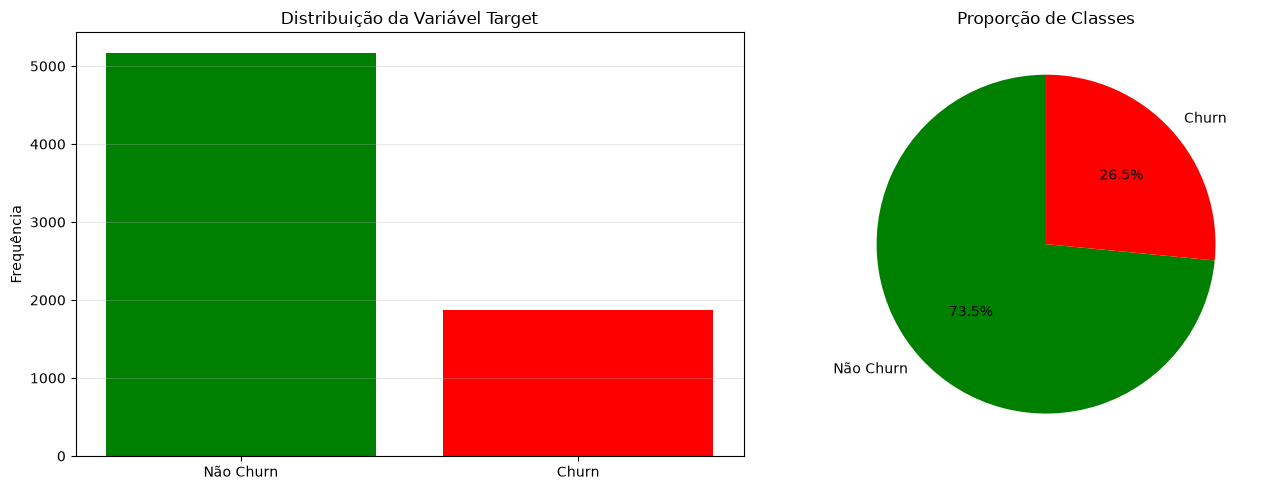


Ratio de balanceamento: 0.36
⚠️ Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.


In [8]:
# Renomear variável `Churn Value` para `target`
df.rename(columns={"Churn Value": "target"}, inplace=True)

print("=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===\n")
target_counts = df["target"].value_counts()
target_percentages = df["target"].value_counts(normalize=True) * 100

print("Contagem:")
print(target_counts)
print("\nPercentual:")
for idx, pct in target_percentages.items():
    label = "Não Churn" if idx == 0 else "Churn"
    print(f"{label} ({idx}): {pct:.2f}%")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
axes[0].bar(["Não Churn", "Churn"], target_counts.values, color=["green", "red"])
axes[0].set_ylabel("Frequência")
axes[0].set_title("Distribuição da Variável Target")
axes[0].grid(axis="y", alpha=0.3)

# Gráfico de pizza
axes[1].pie(
    target_counts.values,
    labels=["Não Churn", "Churn"],
    autopct="%1.1f%%",
    colors=["green", "red"],
    startangle=90,
)
axes[1].set_title("Proporção de Classes")

plt.tight_layout()
plt.show()

# Verificar se há desbalanceamento
ratio = target_counts.min() / target_counts.max()
print(f"\nRatio de balanceamento: {ratio:.2f}")
if ratio < 0.5:
    print(
        "⚠️ Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight."
    )
else:
    print("✓ Dataset razoavelmente balanceado.")